<table style="background-color: transparent; width:100%">
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%" align="center"><font size="7" color="#6366F1"><b>Computación Cuántica</b></font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Temas Selectos de Ingeniería en Computación III</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Facultad de Ingeniería, UNAM | Semestre: 2027-1</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="6" color="#6366F1"><b>Práctica 1: Evolución del estado de un qubit y exploración</b></font></td>
    </tr>
</table>

---
* **Nombre:** Karla Beatriz Rojas Chimal
* **No. de Cuenta:** 320048025
* **Carrera:** Ingeniería en Computación

* **Profesora:** Titular Naomi Itzel Reyes Granados
* **Asistente:** Sebastián González Juárez

---

# Contenido del Notebook
1. [Instalación y Configuración Inicial](#1)
2. [Evolución del Estado de un Qubit (Qiskit)](#2)
    * 2.1. Circuitos y Estados del Qubit
    * 2.2. Análisis de la Evolución
    * 2.3. Representación Matemática
3. [Exploración de IBM Quantum](#3)
4. [Implementación Opcional en PennyLane](#4)

<a id="1"></a>
## 1. Instalación y Configuración Inicial
Preparación del entorno de trabajo

In [ ]:

# ==============================================================================
# SECCIÓN 1: INICIALIZACIÓN
# ==============================================================================

# Instalación silenciosa de las dependencias requeridas
!pip install qiskit pennylane matplotlib --quiet

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

#      |\__/,|   (`\
#    _.|o o  |_   ) )
# --(((---(((--------
#  Renderizado avanzado de la esfera de Bloch

def plot_bloch_state(state, title="Esfera de Bloch"):
    """
    Toma un estado cuántico (alpha, beta) y lo grafica en una esfera de Bloch 3D.
    Basado en las coordenadas de la mecánica cuántica[cite: 1, 3].
    """
    alpha, beta = state

    # Transformación a coordenadas cartesianas del vector de Bloch
    x = 2 * np.real(np.conj(alpha) * beta)
    y = 2 * np.imag(np.conj(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2

    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection="3d")

    # Malla base de la esfera
    u = np.linspace(0, 2 * np.pi, 60)
    v = np.linspace(0, np.pi, 30)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(xs, ys, zs, color="#6366F1", linewidth=0.3, alpha=0.2)

    # Ejes principales (x, y, z)
    ax.plot([-1, 1], [0, 0], [0, 0], color="gray", alpha=0.5)
    ax.plot([0, 0], [-1, 1], [0, 0], color="gray", alpha=0.5)
    ax.plot([0, 0], [0, 0], [-1, 1], color="gray", alpha=0.5)

    # Vector
    ax.quiver(0, 0, 0, x, y, z, color="red", arrow_length_ratio=0.15, linewidth=2)

    # Etiquetas de los ejes
    ax.text(1.1, 0, 0, "x", fontsize=12)
    ax.text(0, 1.1, 0, "y", fontsize=12)
    ax.text(0, 0, 1.1, "|0>", fontsize=12, fontweight='bold')
    ax.text(0, 0, -1.2, "|1>", fontsize=12, fontweight='bold')

    # Ajustes de visualización
    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
    ax.set_box_aspect([1, 1, 1])
    ax.set_title(title, fontsize=14, fontweight='bold', color="#333333")
    ax.set_axis_off()

    plt.show()

print("Inicialización completada.:)")

Inicialización completada.:)


<a id="2"></a>
## 2. Evolución del Estado de un Qubit (Qiskit)

### 2.1. Estados del Qubit
Circuito cuántico de 1 qubit y se aplican 5 compuertas cuánticas, se muestra el estado obtenido en notación de vector, ket y  esfera de Bloch .

1. Estado Inicial |0>
Vector de estado: [1.+0.j 0.+0.j]
Notación Ket:


<IPython.core.display.Math object>

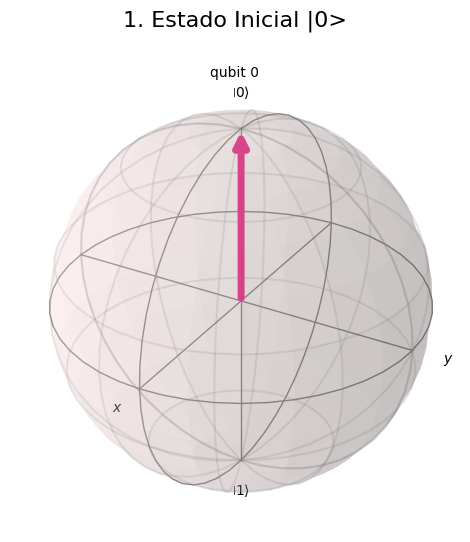



2. Tras compuerta H
Vector de estado: [0.707+0.j 0.707+0.j]
Notación Ket:


<IPython.core.display.Math object>

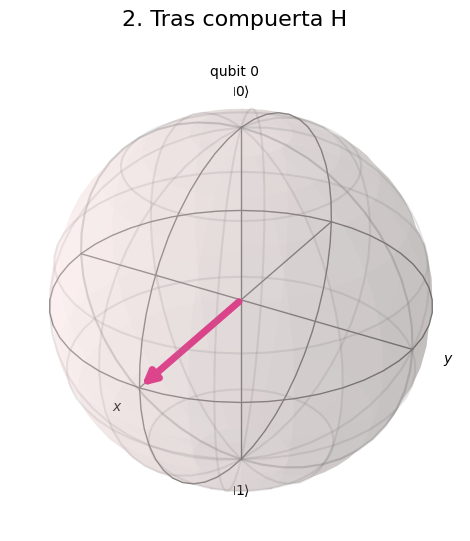



3. Tras compuerta Z
Vector de estado: [ 0.707+0.j -0.707+0.j]
Notación Ket:


<IPython.core.display.Math object>

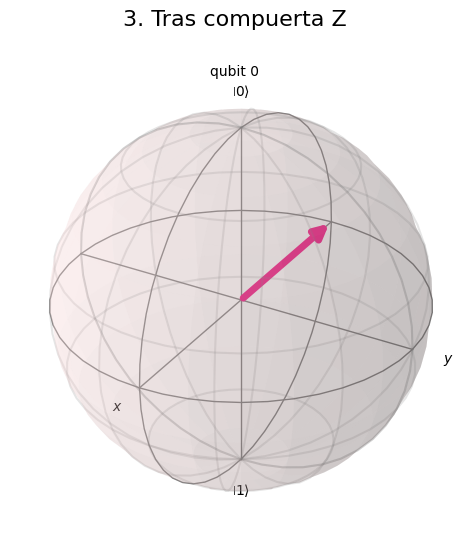



4. Tras compuerta X
Vector de estado: [-0.707+0.j  0.707+0.j]
Notación Ket:


<IPython.core.display.Math object>

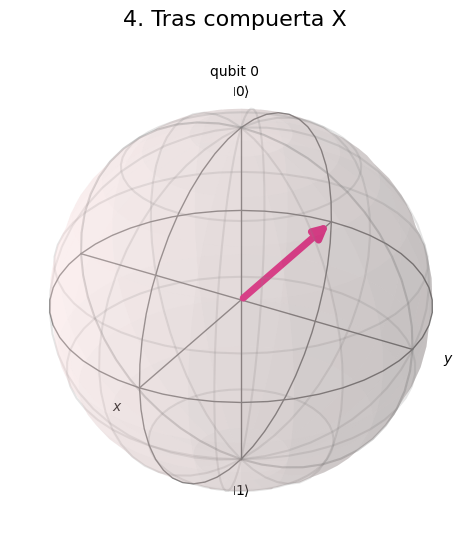



5. Tras compuerta Y
Vector de estado: [0.-0.707j 0.-0.707j]
Notación Ket:


<IPython.core.display.Math object>

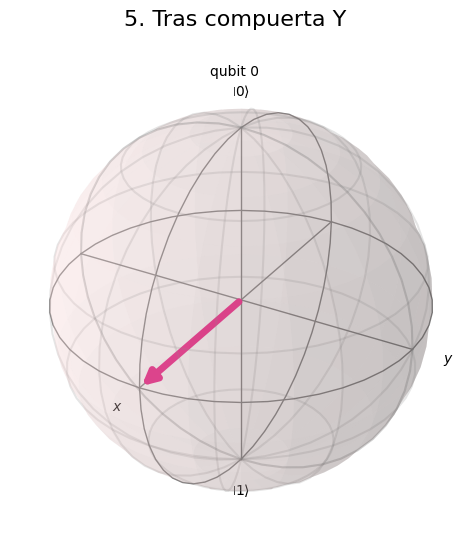



6. Tras compuerta S
Vector de estado: [0.   -0.707j 0.707+0.j   ]
Notación Ket:


<IPython.core.display.Math object>

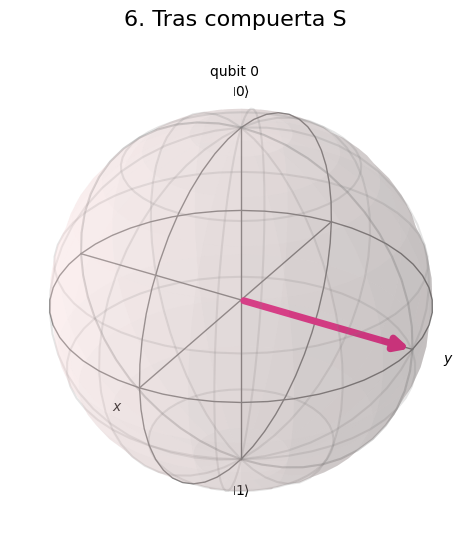

In [ ]:
#  /\_/\
# ( o.o )  OPERACIONES CUÁNTICAS
#  > ^ <   Aplicación secuencial de compuertas
# ==============================================================================

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
# Importamos 'Math' para que las ecuaciones de los Kets se vean perfectas
from IPython.display import display, Math

estados = []
titulos = [
    "1. Estado Inicial |0>",
    "2. Tras compuerta H",
    "3. Tras compuerta Z",
    "4. Tras compuerta X",
    "5. Tras compuerta Y",
    "6. Tras compuerta S"
]

# Inicialización en la base computacional |0>
qc = QuantumCircuit(1)
estado_inicial = Statevector.from_instruction(qc)
estados.append(estado_inicial)

# 1. Compuerta H (Hadamard): Crea superposición
qc.h(0)
estados.append(Statevector.from_instruction(qc))

# 2. Compuerta Z: Rotación fase
qc.z(0)
estados.append(Statevector.from_instruction(qc))

# 3. Compuerta X: Inversor (NOT cuántico)
qc.x(0)
estados.append(Statevector.from_instruction(qc))

# 4. Compuerta Y: Rotación Y
qc.y(0)
estados.append(Statevector.from_instruction(qc))

# 5. Compuerta S: Fase pi/2
qc.s(0)
estados.append(Statevector.from_instruction(qc))

# Despliegue de resultados detallados
for i, estado in enumerate(estados):
    print("="*60)
    print(f"{titulos[i]}")
    print("="*60)
    print(f"Vector de estado: {np.round(estado.data, 3)}")
    print("Notación Ket:")
    # Renderizamos el LaTeX para que se vea como fórmula matemática real
    display(Math(estado.draw('latex_source')))
    print("\n")

    display(plot_bloch_multivector(estado, title=titulos[i]))
    print("\n")


### 2.2. Análisis analítico de la evolución del estado

* **Estado Inicial ($\vert{}0\rangle$):** El estado de un cúbit individual pertenece al espacio $\mathbb{C}^2$ y se expresa mediante el vector columna $\begin{pmatrix} 1 \\ 0 \end{pmatrix}$. Geométricamente, se encuentra en el polo norte de la esfera de Bloch.


* **Tras compuerta Hadamard ($H$):** La compuerta Hadamard toma un estado de la base computacional y lo transforma. Al aplicar la matriz , el sistema resulta en $\frac{1}{\sqrt{2}}(\vert{}0\rangle + \vert{}1\rangle)$. Este resultado es la combinación lineal positiva de los estados base, el cual es el estado $\vert{}+\rangle$. En la representación gráfica, el vector queda alineado sobre el eje X positivo.


* **Tras compuerta Pauli-Z ($\sigma_z$):** La matriz $\sigma_z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$ rota la fase del estado $\vert{}1\rangle$ por un factor de $-1$, invirtiendo su signo relativo, pero deja completamente intacto al estado $\vert{}0\rangle$. Debido a esto, la superposición previa se transforma en la combinación lineal negativa $\frac{1}{\sqrt{2}}(\vert{}0\rangle - \vert{}1\rangle)$, identificada matemáticamente como el estado $\vert{}-\rangle$. Esto provoca que el vector de Bloch se desplace hacia el eje X negativo.


* **Tras compuerta Pauli-X ($\sigma_x$):** Utilizando el operador $\sigma_x = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$, que funciona como un "NOT cuántico". Tras aplicar esta compuerta, se mantiene la posicion del vector, pero hace una inversión sobre la fase global del estado.


* **Tras compuerta Pauli-Y ($\sigma_y$):** La matriz $\sigma_y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$ introduce fases imaginarias complejas . Siguiendo las reglas algebraicas $\sigma_y\vert{}0\rangle = i\vert{}1\rangle$ y $\sigma_y\vert{}1\rangle = -i\vert{}0\rangle$, el vector regresa a el eje X positivo, adquiriendo una fase imaginaria adicional.


* **Tras compuerta de Fase ($S$):** El operador definido como $S = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/2} \end{pmatrix}$ ejecuta una rotación equivalente a $\pi/2$ radianes (90°). Esta última transformación traslada el vector directamente su posición en el eje X positivo hacia el eje Y positivo.



### 2.3. Representación Matemática y Operaciones Sucesivas

El desarrollo algebraico de la secuencia de compuertas se resuelve operando de derecha a izquierda sobre el estado inicial.

$$\vert{}\psi_{final}\rangle = S \cdot Y \cdot X \cdot Z \cdot H \vert{}0\rangle$$

**Paso 1: Compuerta Hadamard ($H$)**


$$H\vert{}0\rangle = \frac{1}{\sqrt{2}}(\vert{}0\rangle + \vert{}1\rangle) = \vert{}+\rangle$$

**Paso 2: Compuerta Pauli-Z ($\sigma_z$)**
Aplicando la linealidad, se invierte el signo de la base $\vert{}1\rangle$:


$$\sigma_z\vert{}+\rangle = \sigma_z\left(\frac{1}{\sqrt{2}}\vert{}0\rangle + \frac{1}{\sqrt{2}}\vert{}1\rangle\right)$$

$$\sigma_z\vert{}+\rangle = \frac{1}{\sqrt{2}}\vert{}0\rangle - \frac{1}{\sqrt{2}}\vert{}1\rangle = \vert{}-\rangle$$

**Paso 3: Compuerta Pauli-X ($\sigma_x$)**
Se intercambian las amplitudes utilizando $\sigma_x\vert{}0\rangle = \vert{}1\rangle$:


$$\sigma_x\vert{}-\rangle = \sigma_x\left(\frac{1}{\sqrt{2}}\vert{}0\rangle - \frac{1}{\sqrt{2}}\vert{}1\rangle\right)$$

$$\sigma_x\vert{}-\rangle = \frac{1}{\sqrt{2}}\vert{}1\rangle - \frac{1}{\sqrt{2}}\vert{}0\rangle = -\vert{}-\rangle$$

**Paso 4: Compuerta Pauli-Y ($\sigma_y$)**
Se introducen fases imaginarias complejas siguiendo $\sigma_y\vert{}0\rangle = i\vert{}1\rangle$ y $\sigma_y\vert{}1\rangle = -i\vert{}0\rangle$:


$$\sigma_y(-\vert{}-\rangle) = \sigma_y\left(-\frac{1}{\sqrt{2}}\vert{}0\rangle + \frac{1}{\sqrt{2}}\vert{}1\rangle\right)$$

$$\sigma_y(-\vert{}-\rangle) = -\frac{1}{\sqrt{2}}(i\vert{}1\rangle) + \frac{1}{\sqrt{2}}(-i\vert{}0\rangle)$$

$$\sigma_y(-\vert{}-\rangle) = -i\left(\frac{1}{\sqrt{2}}\vert{}0\rangle + \frac{1}{\sqrt{2}}\vert{}1\rangle\right) = -i\vert{}+\rangle$$

**Paso 5: Compuerta de Fase ($S$)**
La compuerta $S$ aplica una fase de $\pi/2$, lo que equivale a multiplicar el estado $\vert{}1\rangle$ por $e^{i\pi/2} = i$:


$$S(-i\vert{}+\rangle) = -i \cdot S\left(\frac{1}{\sqrt{2}}\vert{}0\rangle + \frac{1}{\sqrt{2}}\vert{}1\rangle\right)$$

$$S(-i\vert{}+\rangle) = -i\left(\frac{1}{\sqrt{2}}\vert{}0\rangle + \frac{e^{i\pi/2}}{\sqrt{2}}\vert{}1\rangle\right)$$

$$S(-i\vert{}+\rangle) = -i\left(\frac{1}{\sqrt{2}}\vert{}0\rangle + \frac{i}{\sqrt{2}}\vert{}1\rangle\right)$$

$$S(-i\vert{}+\rangle) = -\frac{i}{\sqrt{2}}\vert{}0\rangle - \frac{i^2}{\sqrt{2}}\vert{}1\rangle$$

Sustituyendo $i^2 = -1$:


$$\vert{}\psi_{final}\rangle = \frac{1}{\sqrt{2}}\vert{}1\rangle - \frac{i}{\sqrt{2}}\vert{}0\rangle$$

<a id="3"></a>
## 3. Exploración de IBM Quantum

### 3.1. IBM Quantum Platform
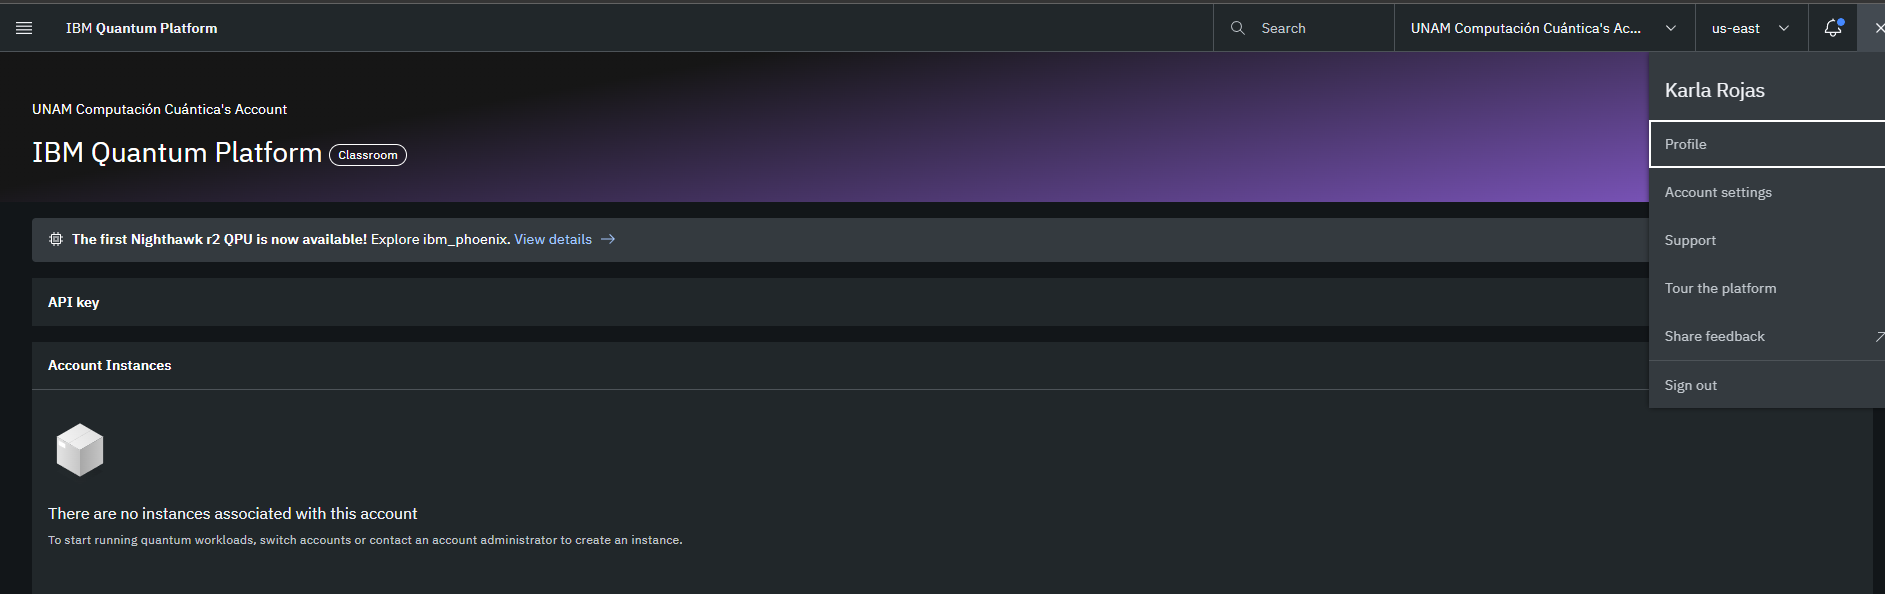

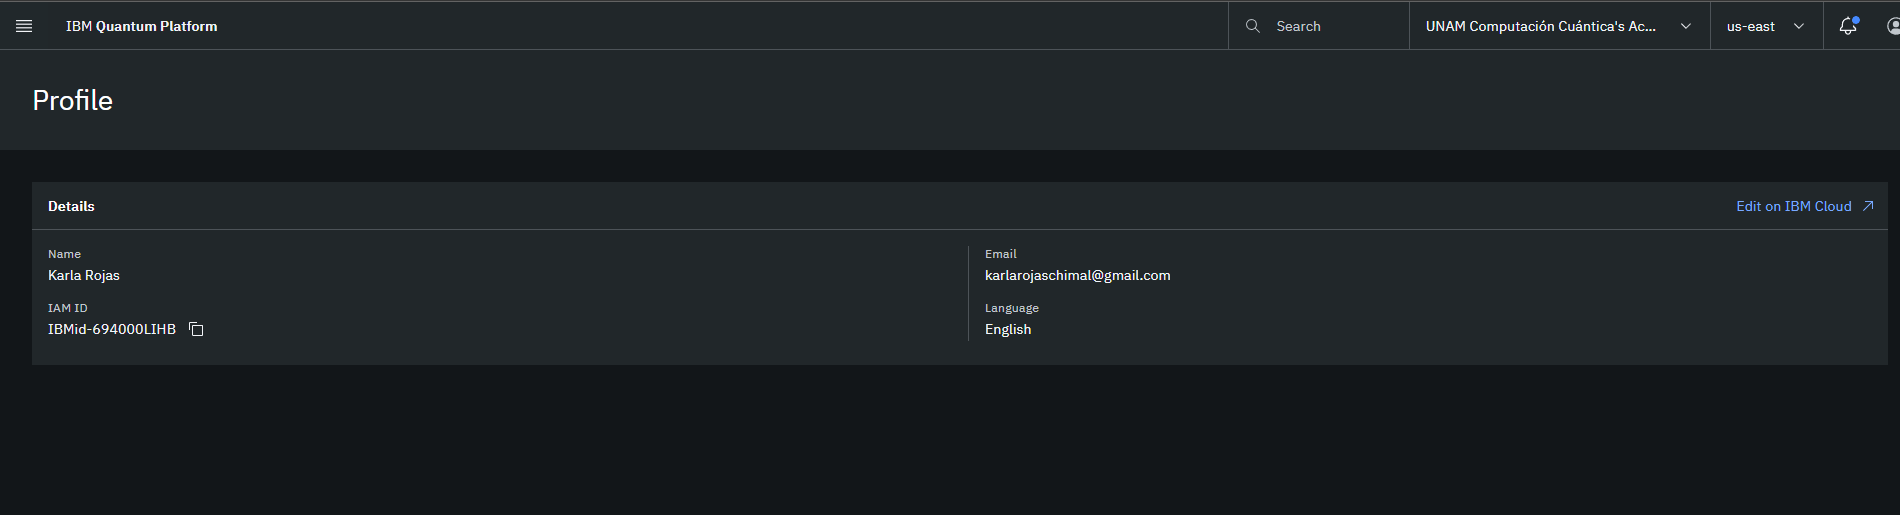

### 3.2. IBM Quantum Composer
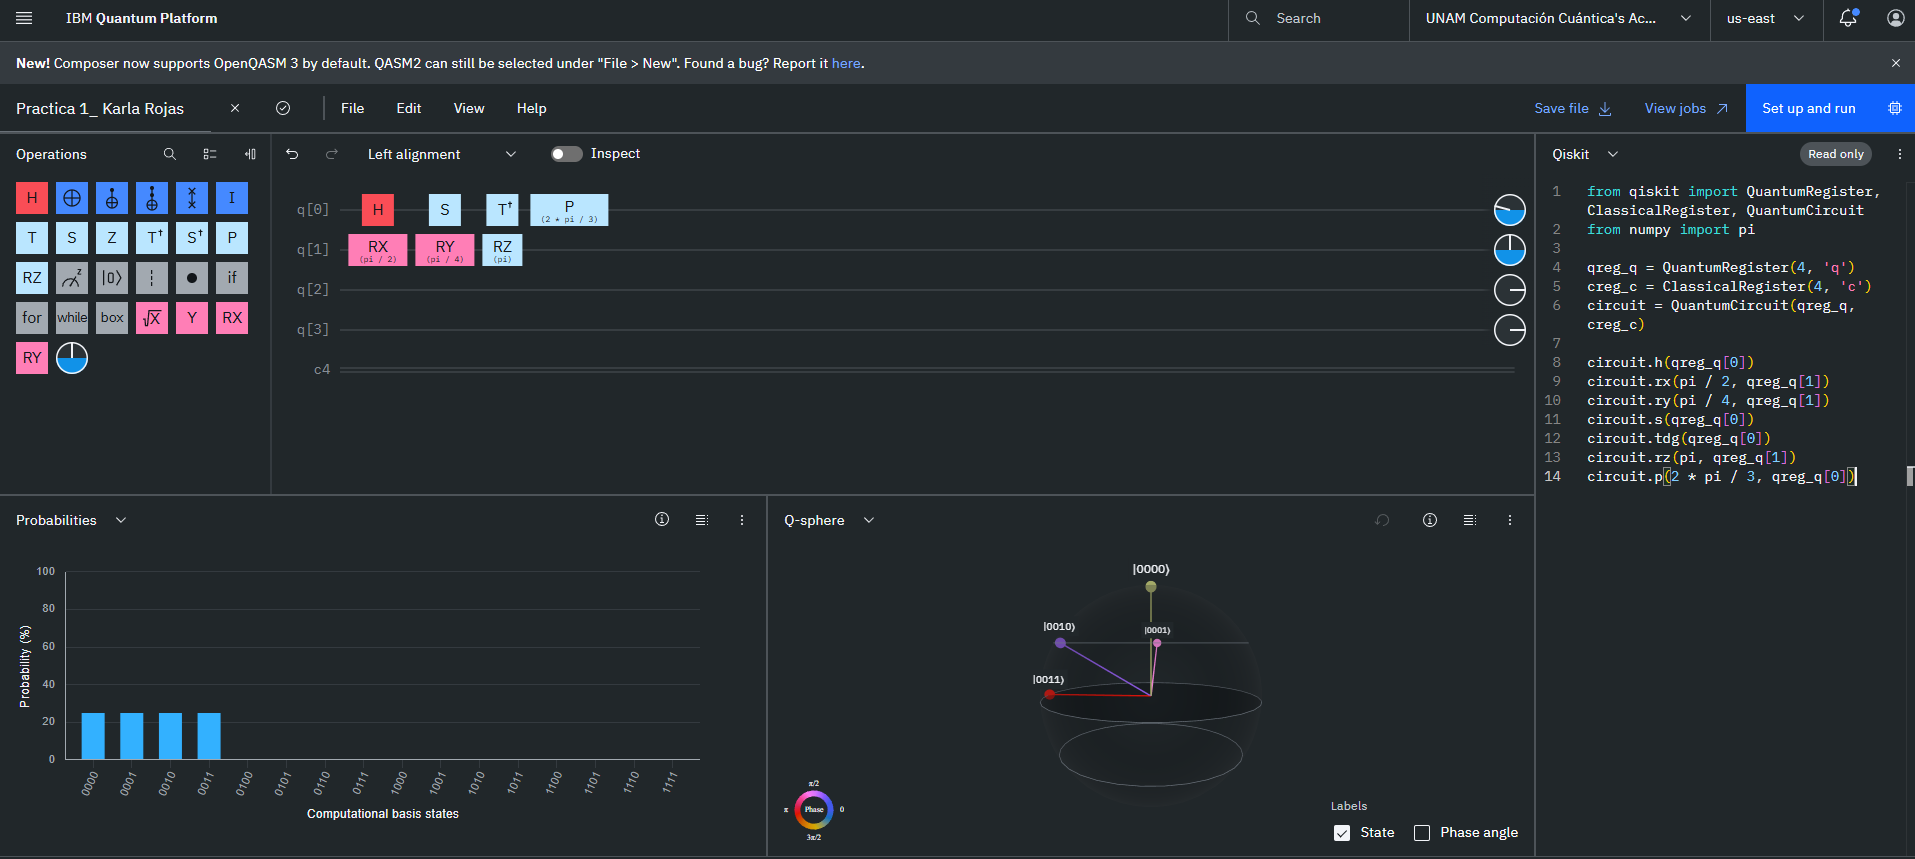

**Descripción de la Interfaz:**
En el IBM Quantum Composer tiene una estructura gráfica orientada a arrastrar y soltar (drag & drop).
Se ven los "wires" que representan los qubits físicos asignados y los registros clásicos.
Asimismo, se identifican los bloques de las compuertas (H, X, Z, CNOT) y los íconos de medición al final del circuito.

<a id="4"></a>
## 4. [Opcional] Implementación en PennyLane

En PennyLane los qubits se identifican mediante `wires` y se ejecutan sobre un dispositivo definido con `qml.device`, como el simulador `default.qubit`[cite: 1].

In [ ]:
#  .======================================.
#  |  Implementación Híbrida: PENNYLANE   |
#  '======================================'
# Construcción del circuito QNode

dev = qml.device("default.qubit", wires=1) # Dispositivo de 1 qubit

@qml.qnode(dev)
def circuito_pennylane():
    # Se aplican las mismas 5 compuertas secuencialmente
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)
    qml.PauliX(wires=0)
    qml.PauliY(wires=0)
    qml.S(wires=0)
    return qml.state() # qml.state() permite obtener el estado cuántico final

resultado_vector = circuito_pennylane()

print("➤ Resultado final en forma de vector (PennyLane):")
print(np.round(resultado_vector, 3))

➤ Resultado final en forma de vector (PennyLane):
[0.   -0.707j 0.707+0.j   ]



### Funciones de medición en PennyLane

En el cómputo cuántico, la medición es un paso fundamental, ya que es el momento en que obtenemos información. Esta medición produce un cambio irreversible del estado, que se conoce como el colapso del estado.

En PennyLane tenemos diferentes funciones para obtener y analizar la información tras una medición o simulación de nuestro circuito.

Cada una tiene una utilidad específica dependiendo si queremos obtener probabilidades teóricas o simular un entorno de hardware real:

1. **`qml.probs(wires=...)` (Probabilidades teóricas):** Esta función regresa las probabilidades analíticas y exactas de medir cada uno de los posibles estados de la base computacional. Nos da la distribución de probabilidad (por ejemplo, qué porcentaje corresponde al estado $\vert{}0\rangle$ y cuál al $\vert{}1\rangle$) sin necesidad de simular un número finito de ejecuciones o *shots*. Es  útil cuando se diseñan algoritmos y se busca entender  cómo la interferencia concentra la probabilidad en los estados que contienen la información útil.


2. **`qml.expval(op)` (Valor esperado):** Retorna el valor esperado analítico de un observable proporcionado. Un observable está asociado a una medición proyectiva, y sus posibles resultados son sus valores propios (eigenvalores). El valor esperado es el promedio estadístico que se obtendría al medir el observable repetidas veces sobre el mismo estado.


3. **`qml.sample(op)` (Muestreo estocástico):** Esta función devuelve muestras individuales de las mediciones. Simula la naturaleza intrínsecamente probabilística y estocástica de una computadora cuántica real. En lugar de un promedio, se obtiene una lista de los resultados (los eigenvalores del observable) obtenidos en cada ejecución (*shot*) del circuito, emulando cómo colapsa el estado físicamente en un dispositivo real.


In [ ]:
# ==============================================================================
# MEDICIÓN ALTERNATIVA: Probabilidades Exactas
# ==============================================================================

dev_probs = qml.device("default.qubit", wires=1)

@qml.qnode(dev_probs)
def circuito_pennylane_probs():
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)
    qml.PauliX(wires=0)
    qml.PauliY(wires=0)
    qml.S(wires=0)
    # Reemplazamos qml.state() por qml.probs()
    return qml.probs(wires=0)

probabilidades = circuito_pennylane_probs()

print("\n➤ Probabilidades de medición [|0⟩, |1⟩]:")
print(f"P(0) = {probabilidades[0]:.4f} ({(probabilidades[0]*100):.1f}%)")
print(f"P(1) = {probabilidades[1]:.4f} ({(probabilidades[1]*100):.1f}%)")


➤ Probabilidades de medición [|0⟩, |1⟩]:
P(0) = 0.5000 (50.0%)
P(1) = 0.5000 (50.0%)
